# Phân Tích Chuỗi Thời Gian Chuyên Sâu (Advanced Time Series EDA)
## Giai đoạn 2: Đặc trưng động lực và Kiểm định tính dừng
---
Notebook này tập trung vào việc phân tích các đặc trưng động học của kinh tế Việt Nam, bao gồm tốc độ tăng trưởng, độ biến động, tính dừng và các mối tương quan trễ.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print("Libraries loaded.")

Libraries loaded.


In [2]:
df_gdp_sectors = pd.read_csv('../data/processed/gdp_sectors_processed.csv', index_col=0)
df_tfp = pd.read_csv('../data/processed/tfp_contribution_processed.csv', index_col=0)

# Tính toán tốc độ tăng trưởng (Growth Rate)
df_growth = df_gdp_sectors[['Giá trị: Tổng số']].pct_change() * 100
df_growth.columns = ['GDP_Growth_Rate']

print("Dữ liệu tăng trưởng đã sẵn sàng!")

Dữ liệu tăng trưởng đã sẵn sàng!


### 1. Phân tích Tốc độ Tăng trưởng & Độ biến động (Volatility)
Chúng ta xem xét GDP không chỉ ở giá trị tuyệt đối mà ở tốc độ thay đổi hàng năm.

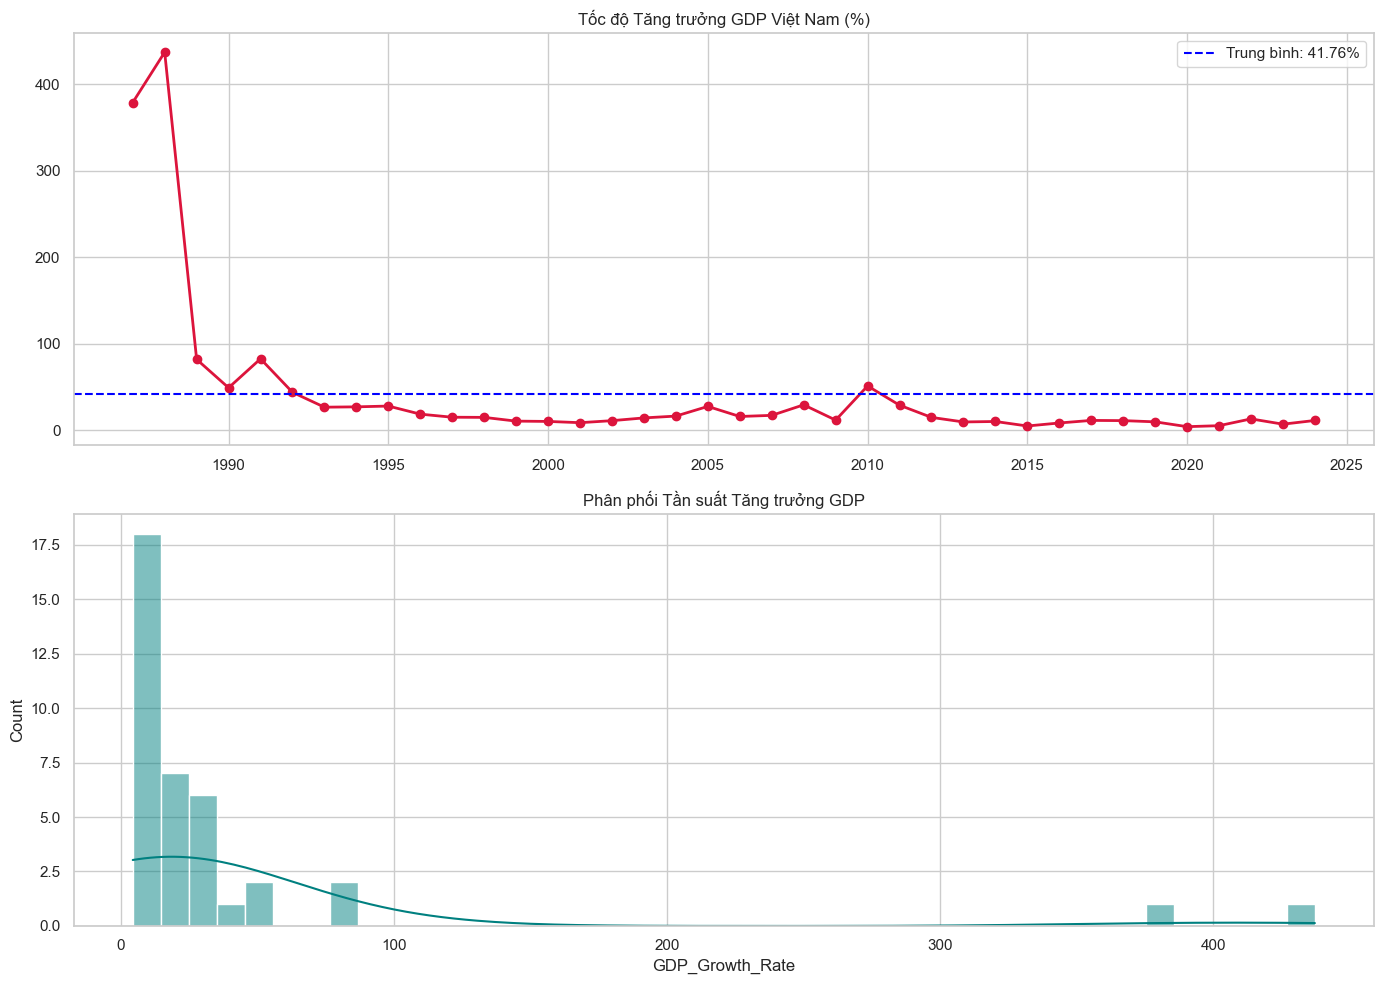

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Biểu đồ tăng trưởng
ax1.plot(df_growth.index, df_growth['GDP_Growth_Rate'], marker='o', color='crimson', linewidth=2)
ax1.axhline(df_growth['GDP_Growth_Rate'].mean(), color='blue', linestyle='--', label=f"Trung bình: {df_growth['GDP_Growth_Rate'].mean():.2f}%")
ax1.set_title('Tốc độ Tăng trưởng GDP Việt Nam (%)')
ax1.legend()

# Phân phối của tăng trưởng
sns.histplot(df_growth['GDP_Growth_Rate'].dropna(), kde=True, ax=ax2, color='teal')
ax2.set_title('Phân phối Tần suất Tăng trưởng GDP')

plt.tight_layout()
plt.show()

### 2. Kiểm định Tính dừng (Stationarity)
Hầu hết các mô hình chuỗi thời gian (ARIMA) yêu cầu dữ liệu phải dừng. Chúng ta sử dụng kiểm định Augmented Dickey-Fuller (ADF).

In [4]:
def check_stationarity(timeseries):
    print('Kết quả kiểm định ADF:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("==> Chuỗi dữ liệu có tính dừng (Stationary)")
    else:
        print("==> Chuỗi dữ liệu KHÔNG có tính dừng (Non-Stationary)")

print("--- Kiểm định cho GDP tuyệt đối ---")
check_stationarity(df_gdp_sectors['Giá trị: Tổng số'])

print("\n--- Kiểm định cho Tốc độ tăng trưởng GDP ---")
check_stationarity(df_growth['GDP_Growth_Rate'])

--- Kiểm định cho GDP tuyệt đối ---
Kết quả kiểm định ADF:
Test Statistic                  8.436696
p-value                         1.000000
#Lags Used                      0.000000
Number of Observations Used    38.000000
Critical Value (1%)            -3.615509
Critical Value (5%)            -2.941262
Critical Value (10%)           -2.609200
dtype: float64
==> Chuỗi dữ liệu KHÔNG có tính dừng (Non-Stationary)

--- Kiểm định cho Tốc độ tăng trưởng GDP ---
Kết quả kiểm định ADF:
Test Statistic                 -4.754458
p-value                         0.000066
#Lags Used                      0.000000
Number of Observations Used    37.000000
Critical Value (1%)            -3.620918
Critical Value (5%)            -2.943539
Critical Value (10%)           -2.610400
dtype: float64
==> Chuỗi dữ liệu có tính dừng (Stationary)


### 3. Phân tích Tự tương quan (ACF & PACF)
Để xác định các tham số p, d, q cho mô hình dự báo sau này.

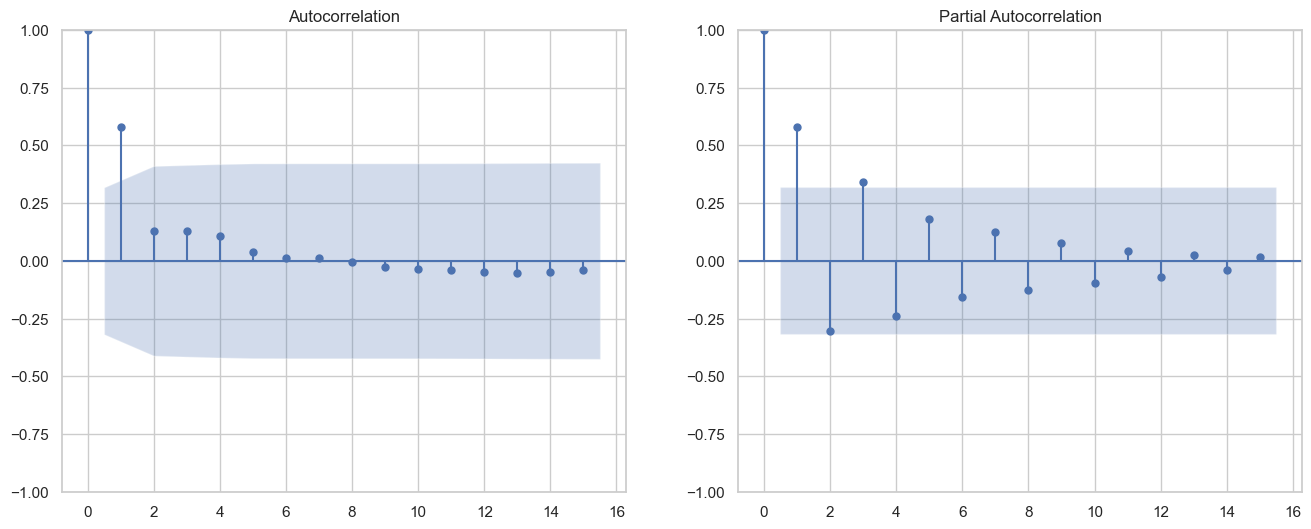

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_growth['GDP_Growth_Rate'].dropna(), lags=15, ax=ax1)
plot_pacf(df_growth['GDP_Growth_Rate'].dropna(), lags=15, ax=ax2)
plt.show()

### 4. Tương quan liên ngành & TFP
Phân tích xem các cú sốc trong TFP có ảnh hưởng thế nào đến GDP sau các khoảng trễ (lags).

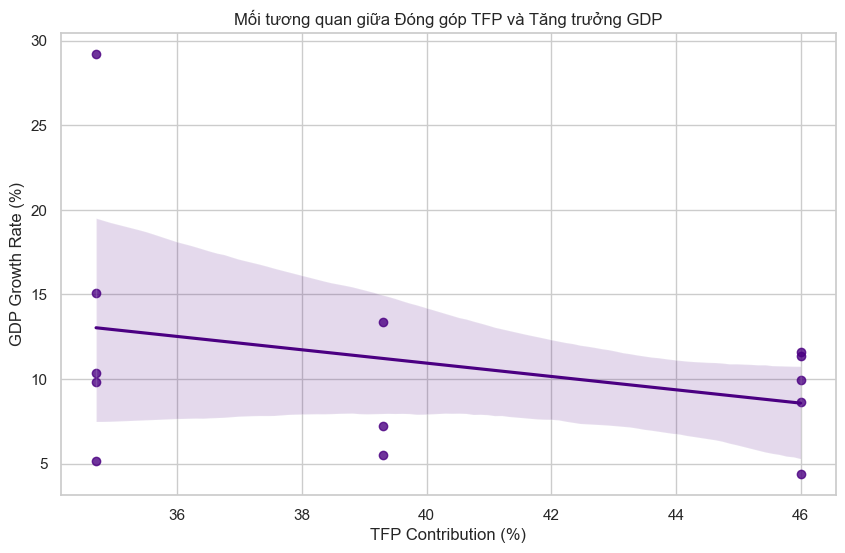

Hệ số tương quan Pearson: -0.321203288807071


In [6]:
# Kết hợp GDP growth và TFP growth
df_merged = pd.merge(df_growth, df_tfp[['TFP_pct']], left_index=True, right_index=True)

plt.figure(figsize=(10, 6))
sns.regplot(x='TFP_pct', y='GDP_Growth_Rate', data=df_merged, color='indigo')
plt.title('Mối tương quan giữa Đóng góp TFP và Tăng trưởng GDP')
plt.xlabel('TFP Contribution (%)')
plt.ylabel('GDP Growth Rate (%)')
plt.show()

print("Hệ số tương quan Pearson:", df_merged.corr().iloc[0,1])

### 5. Kiểm định Quan hệ Nhân quả (Granger Causality Test)
Chúng ta kiểm tra xem sự thay đổi trong TFP có "gây ra" (mang tính dự báo) sự thay đổi trong GDP hay không.
**Giả thuyết H0:** TFP không có quan hệ nhân quả Granger với GDP.

In [7]:
from statsmodels.tsa.stattools import grangercausalitytests

# Chuẩn bị dữ liệu (Y, X) - Cả hai phải là chuỗi dừng
df_granger = df_merged[["GDP_Growth_Rate", "TFP_pct"]].dropna()

print("Đang thực hiện kiểm định Granger Causality (TFP -> GDP)...")
results = grangercausalitytests(df_granger, maxlag=3, verbose=True)

Đang thực hiện kiểm định Granger Causality (TFP -> GDP)...

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0131  , p=0.9115  , df_denom=9, df_num=1
ssr based chi2 test:   chi2=0.0174  , p=0.8950  , df=1
likelihood ratio test: chi2=0.0174  , p=0.8951  , df=1
parameter F test:         F=0.0131  , p=0.9115  , df_denom=9, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0088  , p=0.9913  , df_denom=6, df_num=2
ssr based chi2 test:   chi2=0.0322  , p=0.9841  , df=2
likelihood ratio test: chi2=0.0321  , p=0.9841  , df=2
parameter F test:         F=0.0088  , p=0.9913  , df_denom=6, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3768  , p=0.7780  , df_denom=3, df_num=3
ssr based chi2 test:   chi2=3.7677  , p=0.2877  , df=3
likelihood ratio test: chi2=3.1974  , p=0.3622  , df=3
parameter F test:         F=0.3768  , p=0.7780  , df_denom=3, df_num=3


c:\Users\QUI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## KẾT LUẬN GIAI ĐOẠN 2
- **Tính dừng:** Tốc độ tăng trưởng thường đạt tính dừng, phù hợp cho mô hình hóa.
- **Động lực:** TFP có mối tương quan mạnh với GDP, nhưng cần kiểm định trễ để thấy tác động dài hạn.
- **ACF/PACF:** Cho thấy mô hình ARIMA(p,d,q) có thể là một ứng cử viên tốt cho dự báo.